In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc,
                             classification_report, ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings('ignore')


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/CSE422-Project/mushroom_dataset.csv', sep=';')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (61069, 21)

First 5 rows:


,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w


In [ ]:
print("Column data types:")
print(df.dtypes)

Column data types:
class                    object
cap-diameter            float64
cap-shape                object
cap-surface              object
cap-color                object
does-bruise-or-bleed     object
gill-attachment          object
gill-spacing             object
gill-color               object
stem-height             float64
stem-width              float64
stem-root                object
stem-surface             object
stem-color               object
veil-type                object
veil-color               object
has-ring                 object
ring-type                object
spore-print-color        object
habitat                  object
season                   object
dtype: object


Class distribution:
class
p    33888
e    27181
Name: count, dtype: int64


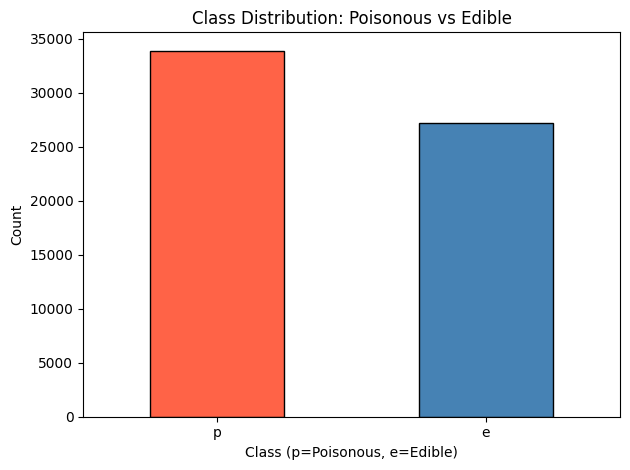

In [ ]:
print("Class distribution:")
print(df['class'].value_counts())

# Bar chart for class balance
df['class'].value_counts().plot(kind='bar', color=['tomato', 'steelblue'], edgecolor='black')
plt.title('Class Distribution: Poisonous vs Edible')
plt.xlabel('Class (p=Poisonous, e=Edible)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

In [ ]:
# Missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
class                       0
cap-diameter                0
cap-shape                   0
cap-surface             14120
cap-color                   0
does-bruise-or-bleed        0
gill-attachment          9884
gill-spacing            25063
gill-color                  0
stem-height                 0
stem-width                  0
stem-root               51538
stem-surface            38124
stem-color                  0
veil-type               57892
veil-color              53656
has-ring                    0
ring-type                2471
spore-print-color       54715
habitat                     0
season                      0
dtype: int64


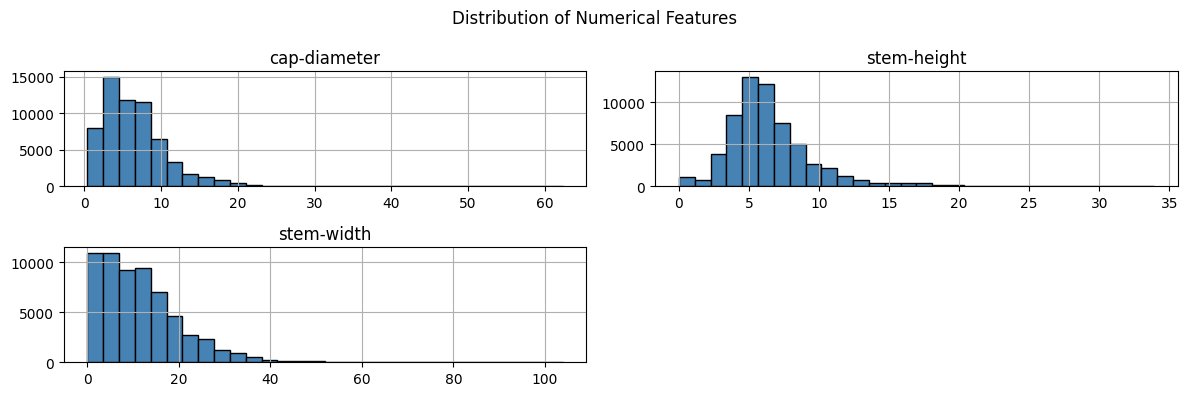

In [ ]:
# Numerical feature distributions
num_cols = ['cap-diameter', 'stem-height', 'stem-width']
df[num_cols].hist(bins=30, figsize=(12, 4), color='steelblue', edgecolor='black')
plt.suptitle('Distribution of Numerical Features')
plt.tight_layout()
plt.savefig('num_distributions.png', dpi=150)
plt.show()

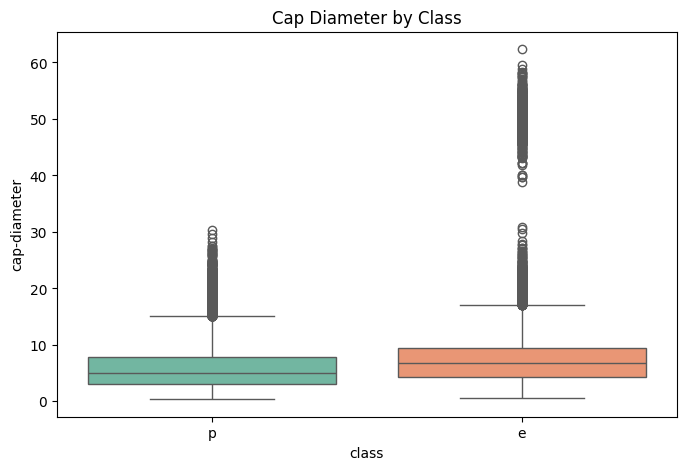

In [ ]:
# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x='class', y='cap-diameter', data=df, palette='Set2')
plt.title('Cap Diameter by Class')
plt.savefig('boxplot_cap_diameter.png', dpi=150)
plt.show()

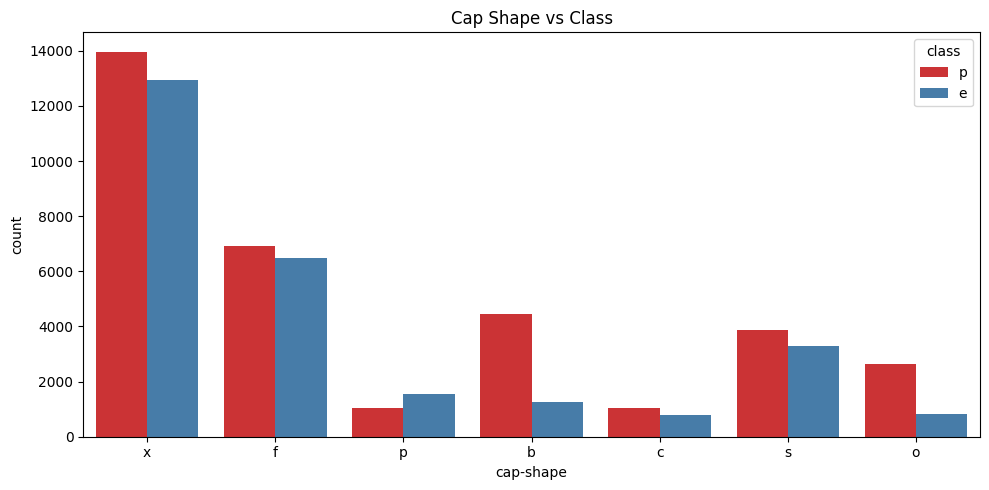

In [ ]:
# Cap shape vs class
plt.figure(figsize=(10, 5))
sns.countplot(x='cap-shape', hue='class', data=df, palette='Set1')
plt.title('Cap Shape vs Class')
plt.tight_layout()
plt.savefig('capshape_vs_class.png', dpi=150)
plt.show()

In [ ]:
# Check missing % per column
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_info = pd.concat([missing_count, missing_pct], axis=1, keys=['Missing Count', 'Percentage (%)'])
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Percentage (%)', ascending=False)

print(missing_info)

                   Missing Count  Percentage (%)
veil-type                  57892       94.797688
spore-print-color          54715       89.595376
veil-color                 53656       87.861272
stem-root                  51538       84.393064
stem-surface               38124       62.427746
gill-spacing               25063       41.040462
cap-surface                14120       23.121387
gill-attachment             9884       16.184971
ring-type                   2471        4.046243


In [ ]:
cols_to_drop = ['veil-type', 'veil-color', 'spore-print-color', 'stem-root']
df.drop(columns=cols_to_drop, inplace=True)
print("Dropped columns:", cols_to_drop)
print("New shape:", df.shape)

Dropped columns: ['veil-type', 'veil-color', 'spore-print-color', 'stem-root']
New shape: (61069, 17)


In [ ]:
# For remaining missing columns
cat_cols_with_null = ['cap-surface', 'gill-attachment', 'gill-spacing',
                      'stem-surface', 'ring-type']
for col in cat_cols_with_null:
    if col in df.columns:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
class                   0
cap-diameter            0
cap-shape               0
cap-surface             0
cap-color               0
does-bruise-or-bleed    0
gill-attachment         0
gill-spacing            0
gill-color              0
stem-height             0
stem-width              0
stem-surface            0
stem-color              0
has-ring                0
ring-type               0
habitat                 0
season                  0
dtype: int64


In [ ]:
le = LabelEncoder()

cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("\nData after encoding (first 3 rows):")
df.head(3)

Categorical columns to encode: ['class', 'cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color', 'stem-surface', 'stem-color', 'has-ring', 'ring-type', 'habitat', 'season']

Data after encoding (first 3 rows):


,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-surface,stem-color,has-ring,ring-type,habitat,season
0,1,15.26,6,2,6,0,2,0,10,16.95,17.09,7,11,1,2,0,3
1,1,16.60,6,2,6,0,2,0,10,17.99,18.19,7,11,1,2,0,2
2,1,14.07,6,2,6,0,2,0,10,17.80,17.74,7,11,1,2,0,3


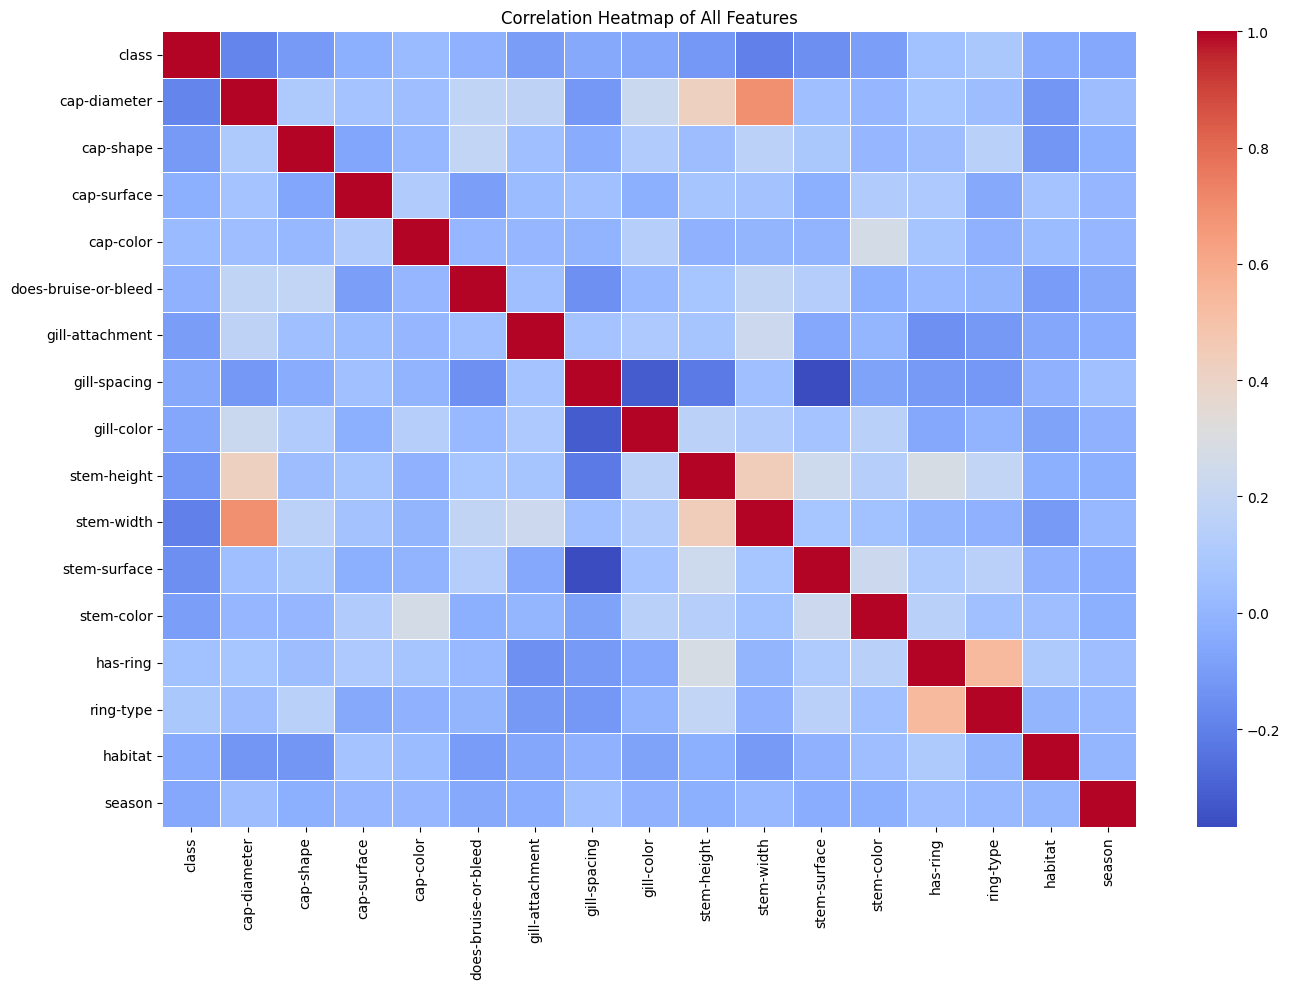

In [ ]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of All Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

In [ ]:
# Correlation with target specifically
print("Correlation with 'class':")
print(df.corr()['class'].sort_values(ascending=False))

Correlation with 'class':
class                   1.000000
ring-type               0.092330
has-ring                0.057559
cap-color               0.026411
does-bruise-or-bleed   -0.019889
cap-surface            -0.026163
habitat                -0.041923
gill-spacing           -0.049022
season                 -0.054046
gill-color             -0.060701
stem-color             -0.094772
gill-attachment        -0.095433
cap-shape              -0.106309
stem-height            -0.121593
stem-surface           -0.153862
cap-diameter           -0.181139
stem-width             -0.197368
Name: class, dtype: float64


In [ ]:
X = df.drop('class', axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (48855, 16)
Test size: (12214, 16)


In [ ]:
# Standard Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.9994268871786475


In [ ]:
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9250040936630096


In [ ]:
nn = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=100,
                   random_state=42, verbose=True)
nn.fit(X_train_scaled, y_train)
y_pred_nn = nn.predict(X_test_scaled)
print("Neural Network Accuracy:", accuracy_score(y_test, y_pred_nn))

Iteration 1, loss = 0.49082111
Iteration 2, loss = 0.24840568
Iteration 3, loss = 0.14645797
Iteration 4, loss = 0.09846003
Iteration 5, loss = 0.07160558
Iteration 6, loss = 0.05388615
Iteration 7, loss = 0.04138747
Iteration 8, loss = 0.03323330
Iteration 9, loss = 0.02693629
Iteration 10, loss = 0.02220181
Iteration 11, loss = 0.01780847
Iteration 12, loss = 0.01531405
Iteration 13, loss = 0.01296388
Iteration 14, loss = 0.01104640
Iteration 15, loss = 0.01000010
Iteration 16, loss = 0.00875146
Iteration 17, loss = 0.00740416
Iteration 18, loss = 0.00659548
Iteration 19, loss = 0.00587069
Iteration 20, loss = 0.00525301
Iteration 21, loss = 0.00473556
Iteration 22, loss = 0.00415936
Iteration 23, loss = 0.00385445
Iteration 24, loss = 0.00357112
Iteration 25, loss = 0.00318841
Iteration 26, loss = 0.00265448
Iteration 27, loss = 0.00331606
Iteration 28, loss = 0.00238625
Iteration 29, loss = 0.00269269
Iteration 30, loss = 0.00216209
Iteration 31, loss = 0.00194268
Iteration 32, los

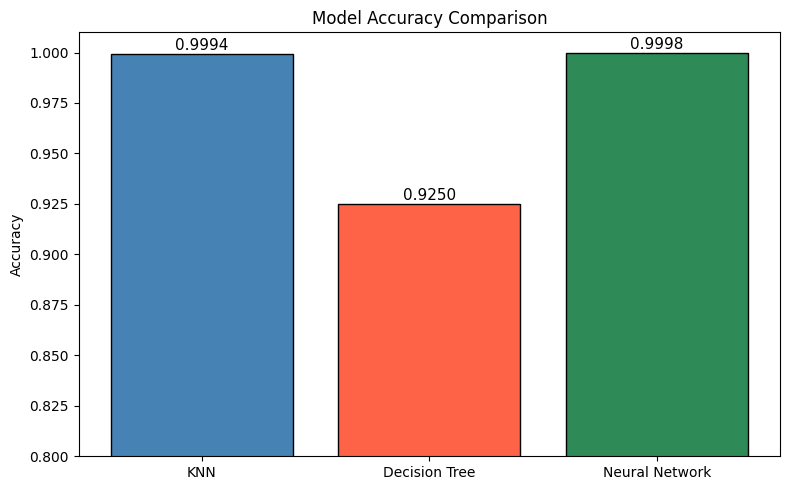

In [ ]:
models = ['KNN', 'Decision Tree', 'Neural Network']
accuracies = [
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_nn)
]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=['steelblue', 'tomato', 'seagreen'], edgecolor='black')
plt.ylim(0.8, 1.01)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{acc:.4f}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150)
plt.show()

In [ ]:
for name, y_pred in [('KNN', y_pred_knn), ('Decision Tree', y_pred_dt), ('Neural Network', y_pred_nn)]:
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=['Edible', 'Poisonous']))


=== KNN ===
              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00      5436
   Poisonous       1.00      1.00      1.00      6778

    accuracy                           1.00     12214
   macro avg       1.00      1.00      1.00     12214
weighted avg       1.00      1.00      1.00     12214


=== Decision Tree ===
              precision    recall  f1-score   support

      Edible       0.92      0.92      0.92      5436
   Poisonous       0.93      0.93      0.93      6778

    accuracy                           0.93     12214
   macro avg       0.92      0.92      0.92     12214
weighted avg       0.93      0.93      0.93     12214


=== Neural Network ===
              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00      5436
   Poisonous       1.00      1.00      1.00      6778

    accuracy                           1.00     12214
   macro avg       1.00      1.00      1.00     12214
weighted avg  

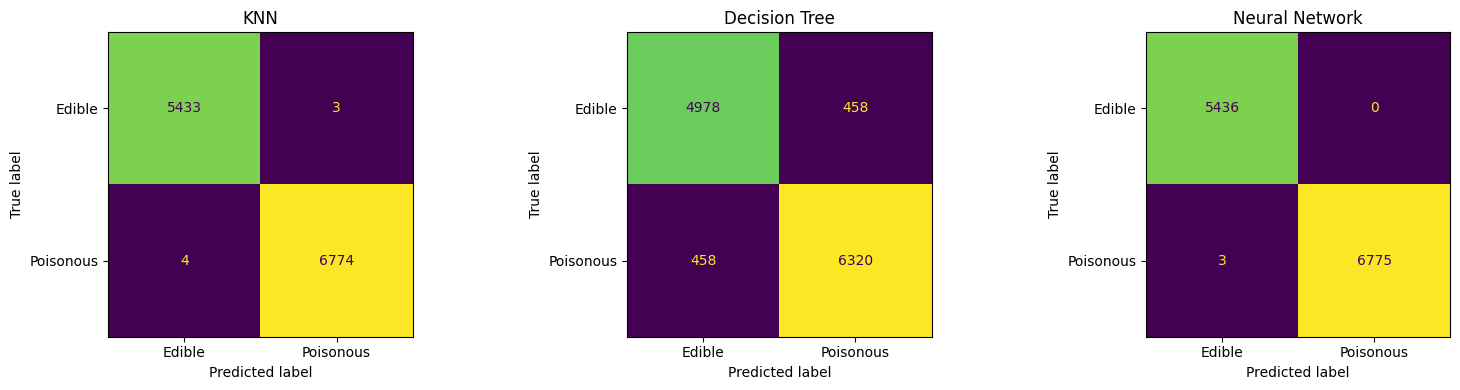

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, y_pred) in zip(axes, [('KNN', y_pred_knn),
                                       ('Decision Tree', y_pred_dt),
                                       ('Neural Network', y_pred_nn)]):

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Edible', 'Poisonous'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f'{name}')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

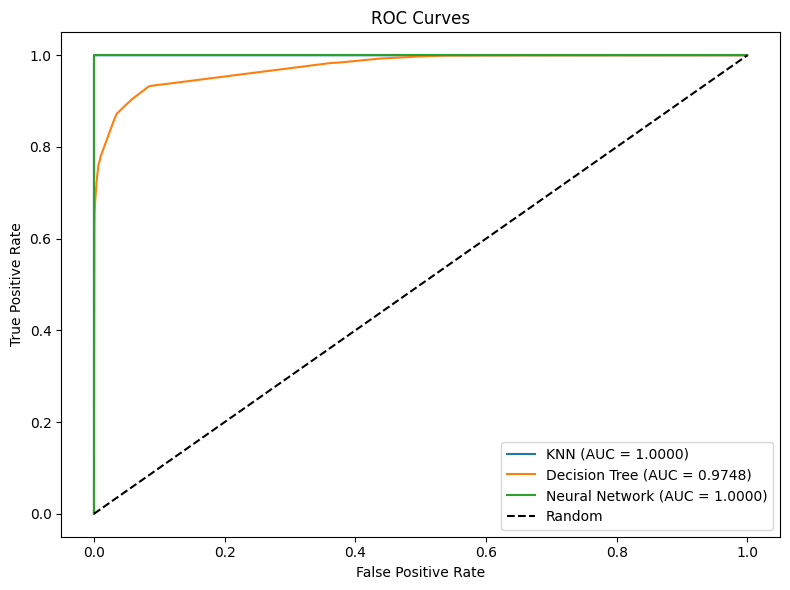

In [ ]:
plt.figure(figsize=(8, 6))

for name, model, X_t in [
    ('KNN', knn, X_test_scaled),
    ('Decision Tree', dt, X_test),
    ('Neural Network', nn, X_test_scaled)
]:
    y_prob = model.predict_proba(X_t)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

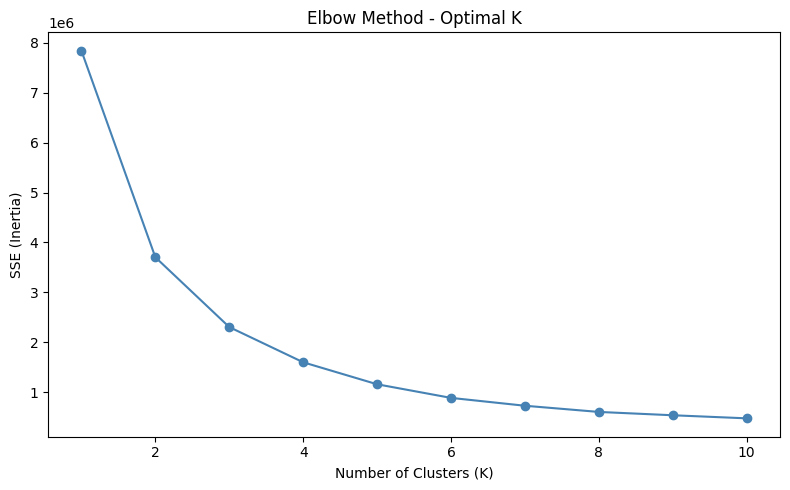

In [ ]:
kmeans_data = df[['cap-diameter', 'stem-width']].copy()
sse = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(kmeans_data)
    sse.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, sse, marker='o', color='steelblue')
plt.title('Elbow Method - Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('SSE (Inertia)')
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150)
plt.show()

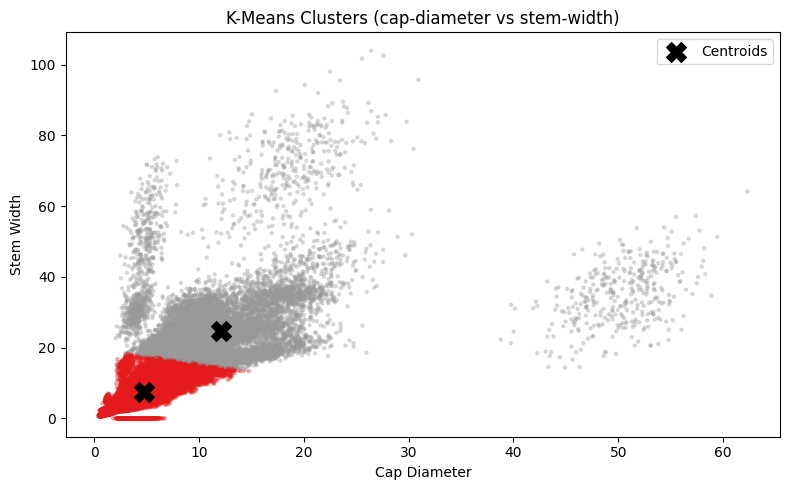

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(kmeans_data)

plt.figure(figsize=(8, 5))
plt.scatter(kmeans_data['cap-diameter'], kmeans_data['stem-width'],
            c=clusters, cmap='Set1', alpha=0.3, s=5)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='black', marker='X', s=200, label='Centroids')
plt.title('K-Means Clusters (cap-diameter vs stem-width)')
plt.xlabel('Cap Diameter')
plt.ylabel('Stem Width')
plt.legend()
plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150)
plt.show()